# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Abdullah Rana

**Date:** Sept 13, 2026 (got extension from professor)

# Q1. Data Cleaning


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

### Q1.1 - Price

In [94]:

airbnb = pd.read_csv('./data/airbnb_hw.csv', low_memory=False)

print(airbnb.shape)
print(airbnb['Price'].dtype)
print(airbnb['Price'].head(10).tolist())
print('missing before cleaning:', airbnb['Price'].isnull().sum())

(30478, 13)
object
['145', '37', '28', '199', '549', '149', '250', '90', '270', '290']
missing before cleaning: 0


In [95]:
# Naive conversion: 
naive = pd.to_numeric(airbnb['Price'], errors='coerce')
print('NaNs created by naive conversion:', naive.isnull().sum())

# Which values? 
has_comma = airbnb['Price'].astype(str).str.contains(',')
print('values containing a comma:', has_comma.sum())
print(airbnb.loc[has_comma, 'Price'].head(10).tolist())

NaNs created by naive conversion: 181
values containing a comma: 181
['1,990', '1,000', '1,200', '1,000', '5,000', '3,000', '1,500', '1,200', '1,800', '1,300']


In [96]:
# Strip thousands separator, then we convert
price = airbnb['Price'].astype(str).str.replace(',', '', regex=False)
price = pd.to_numeric(price, errors='coerce')

print('missing after cleaning:', price.isnull().sum())
print(price.describe())

airbnb['Price'] = price
print(airbnb['Price'].dtype)

missing after cleaning: 0
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64
int64


`Price` loads as an object column instead of a number. Values under $1,000 are stored as plain digit strings like `'145'`, but anything higher keeps the thousands separator, so 1,990 is stored as `'1,990'`. Python cannot parse a comma inside a number, so `pd.to_numeric` turns all 181 of those values into NaN.

That matters because the 181 rows are not a random sample. They are the most expensive listings in the dataset, so losing them would pull the mean down and make the price distribution look much tighter than it actually is. The fix is to strip the commas with `.str.replace(',', '')` before converting. After that all 30,478 values parse and there are 0 missing values. Nothing was actually missing in the original file; the 181 missing values were a formatting problem.

After the commas are removed every value is a whole number, so pandas types the column as `int64`. That works here because there are no missing values left, but on a file that did have gaps the same code would return a float column, since an integer column cannot hold NaN. I also did not remove the extreme values. The maximum is $10,000 per night, which looks unrealistic, but nothing in the row says it is a typo, and removing outliers is an analysis choice rather than a cleaning step. The cleaned column ranges from $10 to $10,000 with a median of $125 and a mean of $163.59.

### Q1.2 - subject_injury

In [97]:
mn = pd.read_csv('./data/mn_police_use_of_force.csv', low_memory=False)

print(mn.shape)
print(mn.columns.tolist())
print()
print(mn['subject_injury'].value_counts(dropna=True))
print()
print('NaN count:', mn['subject_injury'].isnull().sum())

(12925, 13)
['response_datetime', 'problem', 'is_911_call', 'primary_offense', 'subject_injury', 'force_type', 'force_type_action', 'race', 'sex', 'age', 'type_resistance', 'precinct', 'neighborhood']

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64

NaN count: 9848


In [98]:
n_missing = mn['subject_injury'].isnull().sum()
prop_missing = n_missing / len(mn)
print('proportion missing:', round(prop_missing, 4))

# Among rows that were actually filled in
print(mn['subject_injury'].value_counts(normalize=True).round(4))

proportion missing: 0.7619
subject_injury
Yes    0.5301
No     0.4699
Name: proportion, dtype: float64


In [99]:
# Keep NaNs as own visible category so they show up in crosstab
mn['subject_injury_clean'] = mn['subject_injury'].fillna('Missing')
print(mn['subject_injury_clean'].value_counts())

subject_injury_clean
Missing    9848
Yes        1631
No         1446
Name: count, dtype: int64


In [100]:
# Counts
ct = pd.crosstab(mn['force_type'], mn['subject_injury_clean'])
print(ct)
print()

# Row percentages: how often is injury unrecorded for each kind of force?
ct_pct = pd.crosstab(mn['force_type'], mn['subject_injury_clean'], normalize='index')
print((ct_pct * 100).round(1))

subject_injury_clean         Missing    No   Yes
force_type                                      
Baton                              2     0     2
Bodily Force                    7051  1093  1286
Chemical Irritant               1421   131    41
Firearm                            0     2     0
Gun Point Display                 27    33    44
Improvised Weapon                 74    34    40
Less Lethal                       87     0     0
Less Lethal Projectile             0     1     2
Maximal Restraint Technique      170     0     0
Police K9 Bite                    31     2    44
Taser                            985   150   172

subject_injury_clean         Missing     No   Yes
force_type                                       
Baton                           50.0    0.0  50.0
Bodily Force                    74.8   11.6  13.6
Chemical Irritant               89.2    8.2   2.6
Firearm                          0.0  100.0   0.0
Gun Point Display               26.0   31.7  42.3
Improvised W

In [101]:
# Is missingness related to when incident happened?
mn['year'] = mn['response_datetime'].str[:4]
print(pd.crosstab(mn['year'], mn['subject_injury_clean']))
print()
print((pd.crosstab(mn['year'], mn['subject_injury_clean'], normalize='index') * 100).round(1))

subject_injury_clean  Missing   No  Yes
year                                   
2016                      910  604  689
2017                      683  611  633
2018                     1412  231  309
2019                     2021    0    0
2020                     2453    0    0
2021                     2369    0    0

subject_injury_clean  Missing    No   Yes
year                                     
2016                     41.3  27.4  31.3
2017                     35.4  31.7  32.8
2018                     72.3  11.8  15.8
2019                    100.0   0.0   0.0
2020                    100.0   0.0   0.0
2021                    100.0   0.0   0.0


`subject_injury` has three values in the raw file: Yes (1,631), No (1,446), and NaN (9,848). That means 9,848 of 12,925 rows are missing, or about 76.2%.

This is a concern, mainly because the missing values are not spread out randomly. Cross-tabulating the cleaned variable against `force_type` shows the missing rate changing a lot depending on the type of force used. Maximal Restraint Technique and Less Lethal have no injury outcome recorded at all, and Chemical Irritant is missing 89.2% of the time, while Gun Point Display is only missing 26.0%. Bodily Force and Taser, the two largest categories, are both missing about 75%. So the field is least likely to be filled in for several of the more severe categories.

The clearer pattern shows up by year. Missingness is 41.3% in 2016 and 35.4% in 2017, jumps to 72.3% in 2018, and is 100% in 2019, 2020, and 2021. The department appears to have stopped recording subject injury after 2018, which accounts for most of the missing values. That is a change in reporting practice rather than random clerical error.

Because of this I kept the NaN values as an explicit Missing category instead of imputing them. Among the rows that do have a value, 53.0% are Yes, but that figure only describes 2016 through 2018 and should not be reported as an overall injury rate. Filling the NaN values with No would be worse, since it would claim nobody was injured in 9,848 incidents that were never documented.

# Q2.  Shark Attack Data

### Q2.1 - Reading the xls

In [102]:
# GSAF5.xls is the legacy binary .xls format, which pandas reads through xlrd.
# So to access xlrd we: 
# %pip install xlrd and restart kernel

sharks = pd.read_excel('./data/GSAF5.xls')

print(sharks.shape)
print(sharks.columns.tolist())
sharks.head()

(7117, 23)
['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,No injury bump to surfboard,N,1330hrs,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,Bite to foot,N,1700hrs,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,No injury,N,?,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,Bite to left leg,N,1615hrs,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,Bite to rescue torpedo sustained no injury,N,1300hrs,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`read_csv` does not work because `GSAF5.xls` is not a text file. It is the older binary Excel format, so the contents are stored as records inside a compound document rather than as rows separated by commas. `pd.read_excel` reads it, but it needs the `xlrd` package installed to handle legacy `.xls` files, which can be added with `pip install xlrd`.

The file loads with 7,117 rows and 23 columns. The column names show that this spreadsheet has been maintained by hand for a long time. There are two `Case Number` columns, an `href` column and an `href formula` column that hold the same links, a trailing space in the name `Species `, and two unnamed columns at the end.

### Q2.2 - Dropping empty columns

In [103]:
print(sharks.isnull().sum())
print()
print('rows:', len(sharks))

Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              36
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                318
href formula       323
href               321
Case Number        319
Case Number.1      320
original order     318
Unnamed: 21       7116
Unnamed: 22       7115
dtype: int64

rows: 7117


In [104]:
# Two trailing columns are essentially empty 
print(sharks['Unnamed: 21'].dropna().tolist())
print(sharks['Unnamed: 22'].dropna().tolist())

['stopped here']
['Teramo', 'change filename']


In [105]:
sharks = sharks.drop(columns=['Unnamed: 21', 'Unnamed: 22'])
print(sharks.shape)
print(sharks.columns.tolist())

(7117, 21)
['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order']


Two columns contain no data: `Unnamed: 21` and `Unnamed: 22`. Out of 7,117 rows, `Unnamed: 21` has one non-null value and `Unnamed: 22` has two, and none of them are actual data. The values are `'stopped here'`, `'change filename'`, and `'Teramo'`, which look like notes someone left for themselves while editing the spreadsheet. Dropping both leaves 7,117 rows and 21 columns.

I did not drop any other columns. `Time` is about 50% empty and `Species ` is about 44% empty, but an empty cell in those columns means the information was never recorded for that attack, which is still meaningful. A column with no data at all is different from a column with sparse data, and only the first kind should be removed here.

### Q2.3 - Year

In [106]:
print(sharks['Year'].dtype)
print(sharks['Year'].describe())
print()
print('missing:', sharks['Year'].isnull().sum())
print('equal to 0:', (sharks['Year'] == 0).sum())
print()
print(sharks['Year'].value_counts().sort_index().head(12))

float64
count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64

missing: 2
equal to 0: 129

Year
0.0       129
5.0         1
77.0        1
1000.0      1
1500.0      1
1518.0      1
1543.0      1
1554.0      1
1555.0      1
1580.0      1
1595.0      1
1617.0      1
Name: count, dtype: int64


In [107]:
sharks['Year'] = pd.to_numeric(sharks['Year'], errors='coerce')

# Focus on attacks since 1940
sharks = sharks[sharks['Year'] >= 1940]
print('rows since 1940:', len(sharks))
print('range:', sharks['Year'].min(), 'to', sharks['Year'].max())

rows since 1940: 5581
range: 1940.0 to 2026.0


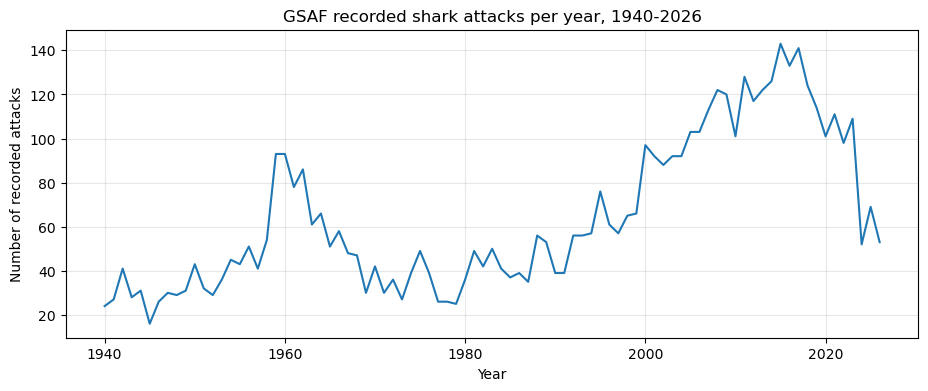

Year
2015.0    143
2016.0    133
2017.0    141
2018.0    124
2019.0    114
2020.0    101
2021.0    111
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Name: count, dtype: int64


In [108]:
counts_by_year = sharks['Year'].value_counts().sort_index()

plt.figure(figsize=(11, 4))
plt.plot(counts_by_year.index, counts_by_year.values)
plt.xlabel('Year')
plt.ylabel('Number of recorded attacks')
plt.title('GSAF recorded shark attacks per year, 1940-2026')
plt.grid(alpha=0.3)
plt.show()

print(counts_by_year.tail(12))

In [109]:
# convert to reading by decade instead of year by year
by_decade = sharks.groupby((sharks['Year'] // 10 * 10).astype(int)).size()
print(by_decade)
print()

# Average per year, using only complete decades. 2020 is 
# left out because file stops partway through 2026.
print('average attacks per year, by decade:')
print((by_decade.loc[1940:2010] / 10).round(1))

n_2020s = (sharks['Year'] >= 2020).sum()
print()
print('2020 through 2026:', n_2020s, 'records over 7 years, about', round(n_2020s / 7, 1), 'per year')

Year
1940     283
1950     467
1960     618
1970     339
1980     438
1990     572
2000    1022
2010    1249
2020     593
dtype: int64

average attacks per year, by decade:
Year
1940     28.3
1950     46.7
1960     61.8
1970     33.9
1980     43.8
1990     57.2
2000    102.2
2010    124.9
dtype: float64

2020 through 2026: 593 records over 7 years, about 84.7 per year


`Year` is stored as a float and ranges from 0 to 2026. Two rows are missing and 129 rows are 0, which the file appears to use to mean the date is unknown. A few rows have values like 5, 77, 1000, and 1500, and then the entries become plausible historical years starting around 1518, with one or two attacks per year scattered through the 1500s and 1600s.

Those early records are not comparable to the modern ones. An attack from 1554 is in the file because someone happened to write it down and the record survived, while an attack from 2015 is in the file because GSAF tracks news reports. Filtering to 1940 and later removes that problem and leaves 5,581 rows.

Attacks are increasing. Averaged by decade, there are about 28 recorded attacks per year in the 1940s, 47 in the 1950s, 62 in the 1960s, 34 in the 1970s, 44 in the 1980s, 57 in the 1990s, 102 in the 2000s, and 125 in the 2010s. The count roughly doubles after 2000 and peaks at 143 attacks in 2015. The 2020s are not a complete decade, but the 593 records from 2020 through 2026 work out to about 85 per year, which is still well above any decade before 2000.

I would not read that as sharks becoming more aggressive. More people are in the water than in 1940, and reporting has improved a lot, especially once GSAF could collect cases online instead of relying on newspaper clippings. The file records reported attacks rather than actual attacks, so better detection looks the same as more incidents. The last few years also drop off, with only 52 records in 2024 and 53 in 2026, but 2026 is a partial year and recent cases take time to be confirmed and entered, so the end of the line is a collection artifact rather than a real decline.

### Q2.4 - Age 

In [124]:
print(sharks['Age'].dtype)
print('blank cells:', sharks['Age'].isna().sum())

# Show every value that is present but will not convert straight to a number
age_str = sharks['Age'].dropna().astype(str).str.strip()
is_number = pd.to_numeric(age_str, errors='coerce').notna()
non_numeric = sorted(set(age_str[~is_number]))

print('present but not a plain number:', len(non_numeric), 'distinct values')
print(non_numeric)

object
blank cells: 1777
present but not a plain number: 78 distinct values
['', '!!', '!2', '!6', '"middle-age"', '"young"', '(adult)', '12 or 13', '13 or 18', '16 to 18', '17 & 16', '17 & 35', '18 months', '18 or 20', '18 to 22', '2 to 3 months', "20's", '20/30', '20?', '20s', '21 & ?', '21 or 26', '21, 34,24 & 35', '22, 57, 31', '23 & 20', '23 & 26', '25 or 28', '25 to 35', '28 & 22', '28 & 26', '28, 23 & 30', '30 & 32', '30 or 36', '30+', '30s', '32 & 30', '33 & 26', '33 & 37', '33 or 37', '34 & 19', '36 & 26', '37, 67, 35, 27,  ? & 27', '40+', '40?', '40s', '45 and 15', '46 & 34', '50 & 30', "50's", '50+', '50s', "60's", '60+', '60s', '6½', '7      &    31', '7 or 8', '8 or 10', '9 & 12', '9 & 60', '9 months', '>50', '?', '? & 19', 'Ca. 33', 'Elderly', 'F', 'M', 'MAKE LINE GREEN', 'Middle age', 'Teen', 'Teens', 'X', 'a minor', 'adult', 'mid-20s', 'mid-30s', 'teen']


In [111]:
age_str = sharks['Age'].astype(str).str.strip()

# Check how many values are already clean numbers?
print('parse straight to number:', pd.to_numeric(age_str, errors='coerce').notnull().sum())

# Pull first run of digits out of whatever cell contains
age_num = age_str.str.extract(r'(\d+)')[0]
sharks['Age_clean'] = pd.to_numeric(age_num, errors='coerce')

print('usable after extraction:', sharks['Age_clean'].notnull().sum())
print('missing:', sharks['Age_clean'].isnull().sum())
print()
print(sharks['Age_clean'].describe())

parse straight to number: 3645
usable after extraction: 3739
missing: 1842

count    3739.000000
mean       28.637336
std        14.828070
min         1.000000
25%        17.000000
50%        25.000000
75%        38.000000
max        87.000000
Name: Age_clean, dtype: float64


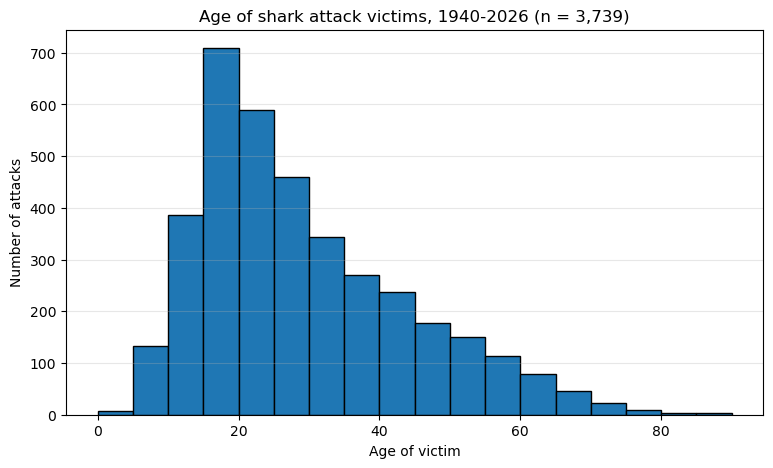

In [112]:
plt.figure(figsize=(9, 5))
plt.hist(sharks['Age_clean'].dropna(), bins=range(0, 95, 5), edgecolor='black')
plt.xlabel('Age of victim')
plt.ylabel('Number of attacks')
plt.title('Age of shark attack victims, 1940-2026 (n = 3,739)')
plt.grid(axis='y', alpha=0.3)
plt.show()

`Age` is stored as text. 1,777 cells are blank, and of the values that are present, 78 distinct ones are not plain numbers. They fall into a few groups: approximate ranges like `'20s'`, `"20's"`, `'30+'`, and `'mid-20s'`; uncertain or multi-victim entries like `'7 or 8'`, `'12 or 13'`, and `'23 & 26'`; words instead of numbers like `'Middle age'`, `'Teen'`, and `'a minor'`; and junk like `'!2'`, `'X'`, `'MAKE LINE GREEN'`, and `'?'`.

Converting directly with `pd.to_numeric` recovers 3,645 values. Using `.str.extract(r'(\d+)')` to pull the first run of digits out of each cell recovers 3,739, so the regex gains about 94 rows by reading `'20s'` as 20 and `'30+'` as 30. That still leaves 1,842 of 5,581 rows, about 33%, without a usable age.

The regex does introduce some bias. Reading `'20s'` as exactly 20 puts the value at the bottom of the range, and `'7 or 8'` becomes 7 only because it appears first in the string. Both push the ages slightly young. I used it anyway because the alternative is discarding every non-numeric cell, and 94 rows is not enough to move the distribution much. I did not try to convert `'Middle age'` or `'Teen'` into numbers, since choosing a value for those would be inventing data.

The cleaned column ranges from 1 to 87 with a median of 25 and a mean of 28.6. The histogram is right-skewed with a clear peak in the late teens and early twenties, and about 60% of victims are between 10 and 30. That most likely reflects who spends time surfing and swimming rather than anything about shark behavior.

### Q2.5 - Proportion male

In [123]:
print(sharks['Sex'].value_counts(dropna=False))

Sex
M        4384
F         730
NaN       451
M           7
?           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
Name: count, dtype: int64


In [114]:
# Normalize case and whitespace, then we keep only unambiguous M / F
sex = sharks['Sex'].astype(str).str.strip().str.upper()
sharks['Sex_clean'] = sex.where(sex.isin(['M', 'F']))

print(sharks['Sex_clean'].value_counts(dropna=False))

Sex_clean
M      4393
F       732
NaN     456
Name: count, dtype: int64


In [115]:
n_known = sharks['Sex_clean'].notnull().sum()
n_male = (sharks['Sex_clean'] == 'M').sum()

print('rows with a usable value:', n_known)
print('male:', n_male)
print('proportion male, of known:', round(n_male / n_known, 4))
print('proportion male, of all rows:', round(n_male / len(sharks), 4))

rows with a usable value: 5125
male: 4393
proportion male, of known: 0.8572
proportion male, of all rows: 0.7871


About 85.7% of victims are male, using the 5,125 rows where sex was recorded. There are 4,393 male victims and 732 female victims.

The column needed cleaning first. Along with `M` and `F` it contains `'M '` with a trailing space and a lowercase `'m'`, which are the same values typed inconsistently, so uppercasing and stripping whitespace merges them. It also contains entries like `'?'`, `'lli'`, `'M x 2'`, and `'M F'`. I set those to NaN rather than guessing, since `'M x 2'` describes two victims in one row and `'M F'` describes one of each, and neither fits in a single-value column. That leaves 456 rows, about 8%, with no usable value.

The denominator matters here. Across all 5,581 rows the male share is 78.7%, but that treats the 456 unknown rows as not male, which is not accurate. The 85.7% figure is conditional on sex having been recorded, and it assumes the unrecorded cases split roughly the same way as the recorded ones.

### Q2.6 - Type

In [116]:
print(sharks['Type'].value_counts(dropna=False))

Type
Unprovoked             4161
Provoked                526
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
NaN                      14
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64


In [117]:
# Now we normalize spacing & capitalization first 
# (ie 'UNprovoked', ' Provoked', 'unprovoked'
# are all the same thing typed three different ways)
type_norm = sharks['Type'].astype(str).str.strip().str.title()
print(type_norm.value_counts())

Type
Unprovoked             4163
Provoked                528
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
Nan                      14
Boat                      7
?                         1
Unconfirmed               1
Unverified                1
Under Investigation       1
Name: count, dtype: int64


In [118]:
sharks['Type_clean'] = type_norm.where(type_norm.isin(['Provoked', 'Unprovoked']), 'Unknown')

print(sharks['Type_clean'].value_counts())
print()
print((sharks['Type_clean'].value_counts(normalize=True) * 100).round(2))

Type_clean
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64

Type_clean
Unprovoked    74.59
Unknown       15.95
Provoked       9.46
Name: proportion, dtype: float64


About 74.59% of attacks since 1940 are unprovoked, or 4,163 of 5,581 rows. Provoked accounts for 528 rows (9.46%) and Unknown accounts for 890 rows (15.95%).

The first cleaning step is capitalization and spacing. `'UNprovoked'`, `'unprovoked'`, and `' Provoked'` are the same categories typed inconsistently, and `.str.strip().str.title()` merges them.

The second step is deciding what to do with everything else, since the column has twelve distinct values. `Invalid` (402 rows), `Questionable` (27), `Unconfirmed`, `Unverified`, and `Under investigation` all mean that nobody is sure the incident was a shark attack, so those map to Unknown without much trouble. `Watercraft` (280), `Sea Disaster` (156), and `Boat` (7) are harder. They are not uncertainty labels, they describe a different kind of incident. Sea Disaster refers to shipwrecks and plane crashes where people ended up in the water, and Watercraft refers to a shark striking a boat rather than a person, so the provoked versus unprovoked distinction does not really apply. I put them in Unknown because the question asks for three categories and there is nowhere else for them to go, but that does lose information.

This is worth noting because it changes the answer. If those 443 rows were counted as unprovoked, which is arguable for the shipwreck cases, the unprovoked share would be about 82%. If only the rows where the provoked or unprovoked call was actually made are counted, it is 4,163 of 4,691, or 88.7%. All three numbers are defensible, and they differ because of a categorization decision rather than anything in the data itself.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** ChatGPT 5.6 - Sol

### *Prompts used

### Initial Prompt: 

I've provided you with the necessary attached files.

Review the entire notebook, both Q1 and Q2. Do not rewrite it wholesale. I first have to evaluate your suggestions one at a time and make my decision on each, so give me specific, separable changes rather than a rewritten notebook.

Your focus should be on:

Q1: cleaning the Airbnb Price variable (attempt, quality, explanation); cleaning subject_injury including the NAs, correct Yes/No values, explanation of missingness; cross-tabulating cleaned subject_injury against force_type (attempt, correctness, interpretation).

Q2: loading the .xls and removing empty columns; cleaning Year (attempt, quality, trend explanation); cleaning Age and making a histogram (attempt, quality, histogram); proportion of male victims; cleaning Type down to three values (attempt, quality); proportion unprovoked.

For each change you propose, give me:

1. A one-line description of the change.
2. Which item it affects.
3. Severity: correctness bug, quality improvement, or style.
4. The actual numeric/percentage change
5. Whether it changes any number I currently report in a markdown answer.

Run the code to verify every number you give me. If you assert a number you did not compute, label it as an estimate.

Separately, at the end, list:
- Anything in my markdown explanations that is contradicted by the notebook's own printed output.
- Any cleaning decision I made that you consider correct but would have done differently, and why.
- Anything you are genuinely unsure about.

Finish with a concise numbered list of your proposed changes, one line each, that I can paste into my notebook verbatim as your recommendations as Phase 2 of the notebook directly requests. 

### Follow Up Prompts: 

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [119]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]